# 02. 초기 100사이클 수명 회귀 — 1차 실행·검토 결과

2026-10-02. 어제의 설계와 추가 Q3·Q4 관측을 구현했다. 피처 A/B/C와 Dummy·Ridge·깊이 제한 RandomForest **22개 후보**를 동일한 Train 36셀의 3-fold CV(seed 42)로 비교했다. 최저 CV MAPE로 선택한 뒤 Train 36셀에 적합하고 Validation 10셀·Batch 2 39셀에 평가했다.

후보 계획·선택 기록·모델 파일·평가 기록을 저장했다. **이미 평가한 Batch 2 결과를 본 뒤 다시 튜닝하면 이번 Test는 독립적인 최종 평가로 해석할 수 없다.** 아래 실행은 저장된 결과가 있으면 그것을 읽는다. 모델 선택 기준으로 Validation/Test를 사용하지 않았지만 EDA에서 전체 Batch 1과 Batch 2 라벨 분포를 이미 관측했다는 한계가 있다.


### 출처·라벨 검토 후 해석 범위 보정

현재 Kaggle v1(2024-04-18)의 4개 파일명·바이트 수가 로컬 파일과 일치한다. 이는 출처의 단서이며 체크섬에 의한 동일성 검증은 아니다. 배포 설명은 2018-02-20을 Figure 4용 저율 진단 자료로 분류한다. 공식 논문의 1차 테스트 배치는 2017-06-30이므로 현재 파일을 논문의 동일 테스트셋으로 부르지 않는다. 과제 가이드가 지정한 Batch 2 평가 역할은 유지한다. [Kaggle 배포 설명](https://www.kaggle.com/datasets/itshpark/data-driven-prediction-of-battery-cycle).

Batch 1의 제공 라벨은 46셀 모두 상세 기록 수+1이고 기록 중 EOL 도달은 없다. Batch 2의 39개 라벨은 최초 QDischarge<0.88 Ah 시점과 일치한다. 공식 정리 코드에는 후속 측정 연결과 미도달 처리 절차가 있으나 연결 대상인 2017-06-30 파일이 현재 프로젝트에는 없다. 기존 점수는 제공 라벨에 대한 기준 결과로 보존하고, 실제 EOL 예측 성능으로 확정하지 않는다. [공식 처리 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m).

추가 원시 전류 확인에서 두 배치의 Cycle 10·100·101 방전 구간 중앙 전류 크기는 약 4 A였다. 따라서 배포 설명만으로 현재 ΔQ 계산에 저율 사이클이 섞였다고 주장하지 않는다. 저율 진단의 구체적 사이클 배치, newstructure 의미, 현재 MAT 라벨 생성 코드는 미확인이다. 관련 근거는 results/modeling의 출처 메타데이터·라벨·전류 진단표에 보존한다. 이번 출처 검토로 모델·점수를 변경하지 않았다.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.models import run_experiment
OUT = ROOT / "results/modeling"
if not (OUT / "test_evaluation.json").exists():
    run_experiment(ROOT)
else:
    print("Batch 2 재평가 없이 저장된 1차 결과를 읽습니다.")
cv = pd.read_csv(OUT / "cv_candidate_results.csv")
performance = pd.read_csv(ROOT / "results/model_performance.csv")
predictions = pd.read_csv(OUT / "cell_predictions.csv")
selected = json.loads((OUT / "selected_model.json").read_text())
ledger = json.loads((OUT / "test_evaluation.json").read_text())
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "AppleGothic" if sys.platform == "darwin" else "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
print("선택:", selected["id"], selected["features"])
print("선택시각 UTC:", selected["selected_at_utc"], "평가시각 UTC:", ledger["evaluated_at_utc"])


Batch 2 재평가 없이 저장된 1차 결과를 읽습니다.
선택: Ridge_C_policy_alpha0.1 ['q_diff_100_2', 't_max_100', 'delta_q_log_var', 'charge_c1_rate', 'charge_c2_rate', 'charge_switch_soc']
선택시각 UTC: 2026-10-02T00:06:00.112943+00:00 평가시각 UTC: 2026-10-02T00:06:00.201748+00:00


## 1. 피처 계산과 누수 방지

A는 총 용량 변화와 초기 최고온도, B는 A에 전압별 ΔQ(V) 로그 분산, C는 B에 정책의 첫 C-rate·두 번째 C-rate·전환 SOC를 추가했다. 모든 측정값은 Cycle 100 이내이며 타깃·종료 기록량은 제외했다. 원본 사이클·배열·전압 축·유한성을 확인했고 오류를 임의 보간하지 않았다.

스케일러는 Ridge Pipeline 안에서 각 CV fold의 학습 부분에서 적합했다. 최종 스케일러는 Train 36셀에서 적합했고 Validation/Test에는 적용만 했다. 분할 ID는 어제 저장한 명세를 유지했다. 데이터가 적고 정책이 양쪽에 겹치므로 새로운 정책 일반화에 대한 검증은 충분하지 않다.


In [2]:
features_b1 = pd.read_csv(OUT / "batch1_features.csv")
features_b2 = pd.read_csv(OUT / "batch2_features.csv")
for batch in ["batch1", "batch2"]:
    audit = pd.read_csv(OUT / f"{batch}_input_audit.csv")
    display(audit.groupby("status").size().rename("셀수").to_frame())
display(features_b1[["cell_id", "split"] + selected["features"]].head())
display(pd.read_csv(OUT / "cv_fold_cells.csv").groupby("cv_fold").size().rename("검증_셀수").to_frame())


,셀수
status,
passed,46


,셀수
status,
excluded_missing_label,8
passed,39


,cell_id,split,q_diff_100_2,t_max_100,delta_q_log_var,charge_c1_rate,charge_c2_rate,charge_switch_soc
0,Batch1_c00,train,0.005223,35.994705,-5.014861,3.6,3.6,80.0
1,Batch1_c01,train,0.005328,34.712265,-5.013960,3.6,3.6,80.0
2,Batch1_c02,train,0.005018,35.127342,-4.737000,3.6,3.6,80.0
3,Batch1_c03,val,0.005027,31.691414,-4.442613,4.0,4.0,80.0
4,Batch1_c04,val,0.004229,35.651741,-4.647744,4.0,4.0,80.0


,검증_셀수
cv_fold,
1,12
2,12
3,12


### 수명 라벨의 관측 상태 확인

라벨이 숫자로 존재하는지와 실제 수명 종료를 측정했는지는 다르다. 원본 summary에서 Cycle 2 이후 QDischarge가 처음 0.88 Ah 미만으로 내려간 사이클을 찾아 제공 라벨과 비교한다. Cycle 1의 0 용량은 제외한다. 0.88 Ah는 공칭 1.1 Ah의 80%이며 셀별 초기 용량의 80%로 다시 계산하지 않는다.

- `observed_EOL_label_matches`: 기록에서 경계 통과를 관측했고 제공 라벨과 일치함.
- `observed_EOL_label_differs`: 기록에서 경계 통과를 관측했지만 제공 라벨과 다름. 추가 조사 대상.
- `unobserved_EOL_in_current_record`: 현재 기록 안에서 경계 통과가 없음. 제공 라벨을 정확한 최종 수명으로 확정하지 않음.
- `missing_or_invalid_label`: 제공 수명 라벨이 결측 또는 비정상임. EOL 관측 여부는 별도 열에 보존함.

‘기록 수+1’ 일치는 종료 처리의 단서이며 해당 숫자를 생성한 코드를 확정한 것은 아니다. 미관측 셀의 실제 수명을 마지막 사이클로 교체하거나 +1을 삭제하지 않는다. 기존 모델은 제공 라벨에 대한 기준 실험으로 보존한다. 수명 라벨의 출처가 확인되기 전에는 후속 피처 축소·모델 개선을 실제 EOL 예측 개선이라고 평가하지 않는다.


In [1]:
from src.preprocess import load_batch_summary
import h5py

label_rows = []
for batch_name, filename in [
    ("Batch1", "2017-05-12_batchdata_updated_struct_errorcorrect.mat"),
    ("Batch2", "2018-02-20_batchdata_updated_struct_errorcorrect.mat"),
]:
    path = ROOT / "data" / filename
    with h5py.File(path, "r") as source:
        for _, row in load_batch_summary(path, batch_name).iterrows():
            usable = (row.cycles >= 2) & np.isfinite(row.QDischarge)
            crossings = np.flatnonzero(usable & (row.QDischarge < 0.88))
            observed_cycle = float(row.cycles[crossings[0]]) if len(crossings) else np.nan
            valid_label = np.isfinite(row.cycle_life) and row.cycle_life > 0
            if not valid_label:
                status = "missing_or_invalid_label"
            elif not len(crossings):
                status = "unobserved_EOL_in_current_record"
            elif observed_cycle == row.cycle_life:
                status = "observed_EOL_label_matches"
            else:
                status = "observed_EOL_label_differs"
            detail = source[source["batch/cycles"][int(row.cell_idx), 0]]
            records = detail["Qd"].shape[0]
            label_rows.append({
                "batch": batch_name, "cell_id": row.cell_id,
                "provided_cycle_life": row.cycle_life, "status": status,
                "observed_EOL_cycle": observed_cycle,
                "last_record_cycle": float(row.cycles[-1]),
                "last_q_Ah": float(row.QDischarge[-1]),
                "detail_records": records,
                "label_equals_records_plus_one": bool(valid_label and row.cycle_life == records + 1),
            })
label_audit = pd.DataFrame(label_rows)
manifest = pd.read_csv(ROOT / "results/train_val_split_cells.csv")
label_audit = label_audit.merge(manifest[["cell_id", "split"]], on="cell_id", how="left", validate="one_to_one")
label_audit.loc[label_audit["batch"].eq("Batch2"), "split"] = "test_pool"
assert len(label_audit) == 93 and label_audit.cell_id.is_unique
assert label_audit.query('batch == "Batch1"').status.eq("unobserved_EOL_in_current_record").all()
assert label_audit.status.eq("observed_EOL_label_matches").sum() == 39
assert label_audit.status.eq("missing_or_invalid_label").sum() == 8
label_summary = label_audit.groupby(["batch", "split", "status"]).size().rename("cells").reset_index()
display(label_summary)
display(label_audit.query('batch == "Batch1"')[
    ["cell_id", "provided_cycle_life", "last_record_cycle", "last_q_Ah", "status"]
].head())
label_audit.to_csv(OUT / "review_label_observation_status.csv", index=False)
label_summary.to_csv(OUT / "review_label_observation_summary.csv", index=False)


,batch,split,status,cells
0,Batch1,train,unobserved_EOL_in_current_record,36
1,Batch1,val,unobserved_EOL_in_current_record,10
2,Batch2,test_pool,missing_or_invalid_label,8
3,Batch2,test_pool,observed_EOL_label_matches,39


,cell_id,provided_cycle_life,last_record_cycle,last_q_Ah,status
0,Batch1_c00,1190.0,1189.0,1.026210,unobserved_EOL_in_current_record
1,Batch1_c01,1179.0,1178.0,1.038225,unobserved_EOL_in_current_record
2,Batch1_c02,1177.0,1176.0,1.043279,unobserved_EOL_in_current_record
3,Batch1_c03,1226.0,1225.0,0.970921,unobserved_EOL_in_current_record
4,Batch1_c04,1227.0,1226.0,1.021960,unobserved_EOL_in_current_record


### 다중공선성 진단과 도메인 검토·판단 보류

Train 36셀만 사용해 Pearson 상관과 VIF를 확인한다. VIF는 각 변수를 다른 입력으로 회귀해 계산하며 Ridge 규제 후의 값은 아니다. 정책이 학습·평가 양쪽에 있는 것과 변수 간 다중공선성은 별개다.

C1·전환 SOC 상관은 −0.842, VIF는 9.56·6.55다. C1은 첫 충전 속도, 전환 SOC는 그 속도의 적용 구간이다. 6C(50%)-3.6C는 0~50%를 6C, 50~80%를 3.6C로 충전하고 이후는 공통 1C CC-CV다. SOC=80%에서는 두 번째 고속 구간 길이가 0이다. [논문 Methods](https://www.nature.com/articles/s41560-019-0356-8).

**C1·전환 SOC는 검토 대상으로 남기며 유지·축소의 최종 판단을 보류한다. 현재 기준 모델에는 둘 다 유지한다.** 속도와 적용 구간은 다른 물리적 정보이므로 높은 상관만으로 삭제하지 않는다. SOC 제외 또는 C1 제외로 VIF가 줄어도 성능 개선을 입증한 것은 아니다. 후속 Train CV에서 기존·축소·도메인 대체 구성을 비교해 판단한다. 아래 코드는 진단만 수행하며 모델 및 Test 결과를 변경하지 않는다. Test 관측 이후의 추가 실험은 탐색으로 구분한다.


In [1]:
selected_features = json.loads((OUT / "selected_model.json").read_text())["features"]
train_inputs = features_b1.loc[features_b1["split"].eq("train"), selected_features]
assert len(train_inputs) == 36 and np.isfinite(train_inputs.to_numpy()).all()
correlations = train_inputs.corr()
display(correlations.round(3))

def calculate_vif(frame):
    assert (frame.std(ddof=0) > 0).all(), "상수 변수는 별도 검토가 필요합니다."
    values = ((frame - frame.mean()) / frame.std(ddof=0)).to_numpy()
    rows = []
    for i, column in enumerate(frame.columns):
        target = values[:, i]
        others = np.column_stack([np.ones(len(frame)), np.delete(values, i, axis=1)])
        residual = target - others @ np.linalg.lstsq(others, target, rcond=None)[0]
        tolerance = float((residual @ residual) / (target @ target))
        rows.append({"feature": column, "VIF": 1 / tolerance if tolerance > 1e-12 else np.inf})
    return pd.DataFrame(rows)

vif = calculate_vif(train_inputs)
assert np.isclose(vif.set_index("feature").loc["charge_c1_rate", "VIF"], 9.562382, atol=1e-5)
display(vif.round(3))
reduced = pd.concat([
    vif.assign(configuration="six_features"),
    calculate_vif(train_inputs.drop(columns="charge_switch_soc")).assign(configuration="without_switch_soc"),
    calculate_vif(train_inputs.drop(columns="charge_c1_rate")).assign(configuration="without_c1"),
], ignore_index=True)
display(reduced.round(3))
correlations.to_csv(OUT / "review_feature_correlations_train.csv")
vif.to_csv(OUT / "review_feature_vif_train.csv", index=False)
reduced.to_csv(OUT / "review_vif_reduced_candidates.csv", index=False)


,q_diff_100_2,t_max_100,delta_q_log_var,charge_c1_rate,charge_c2_rate,charge_switch_soc
q_diff_100_2,1.000,0.114,-0.609,-0.179,-0.566,-0.158
t_max_100,0.114,1.000,0.287,0.419,-0.229,-0.376
delta_q_log_var,-0.609,0.287,1.000,0.641,0.165,-0.270
charge_c1_rate,-0.179,0.419,0.641,1.000,-0.214,-0.842
charge_c2_rate,-0.566,-0.229,0.165,-0.214,1.000,0.411
charge_switch_soc,-0.158,-0.376,-0.270,-0.842,0.411,1.000


,feature,VIF
0,q_diff_100_2,2.731
1,t_max_100,1.337
2,delta_q_log_var,3.863
3,charge_c1_rate,9.562
4,charge_c2_rate,1.768
5,charge_switch_soc,6.552


,feature,VIF,configuration
0,q_diff_100_2,2.731,six_features
1,t_max_100,1.337,six_features
2,delta_q_log_var,3.863,six_features
3,charge_c1_rate,9.562,six_features
4,charge_c2_rate,1.768,six_features
5,charge_switch_soc,6.552,six_features
6,q_diff_100_2,2.662,without_switch_soc
7,t_max_100,1.337,without_switch_soc
8,delta_q_log_var,3.122,without_switch_soc
9,charge_c1_rate,2.192,without_switch_soc


## 2. Train 내부 모델·피처 비교

MAPE 평균이 최소인 후보를 선택했다. 같은 seed·fold를 모든 후보에 적용했으며 fold 표준편차는 분할별 변동의 참고치다. 여러 후보를 비교한 최저 CV 점수도 선택 편향을 포함할 수 있어 새로운 배치의 성능을 보장하지 않는다.


,candidate_id,model,feature_set,parameters,CV_MAPE_mean_pct,CV_MAPE_std_pct,fold1_MAPE_pct,fold2_MAPE_pct,fold3_MAPE_pct
0,Ridge_C_policy_alpha0.1,Ridge,C_policy,"{""alpha"": 0.1}",9.8809,1.1101,11.0348,8.8205,9.7875
1,Ridge_C_policy_alpha1.0,Ridge,C_policy,"{""alpha"": 1.0}",10.1499,0.9665,10.9249,9.0669,10.4578
2,Ridge_C_policy_alpha10.0,Ridge,C_policy,"{""alpha"": 10.0}",11.5482,1.0552,12.6186,10.5089,11.5170
3,Ridge_B_voltage_alpha1.0,Ridge,B_voltage,"{""alpha"": 1.0}",12.0680,0.8251,13.0199,11.6261,11.5580
4,Ridge_B_voltage_alpha10.0,Ridge,B_voltage,"{""alpha"": 10.0}",12.0844,1.6773,13.6632,10.3235,12.2665
5,Ridge_B_voltage_alpha0.1,Ridge,B_voltage,"{""alpha"": 0.1}",12.1929,1.0535,13.2977,12.0814,11.1996
6,RF_C_policy_depth2_leaf3,RandomForest,C_policy,"{""max_depth"": 2, ""min_samples_leaf"": 3}",14.2603,3.9910,17.0463,16.0465,9.6883
7,RF_C_policy_depth3_leaf3,RandomForest,C_policy,"{""max_depth"": 3, ""min_samples_leaf"": 3}",14.2722,4.1070,17.1213,16.1308,9.5645
8,RF_B_voltage_depth3_leaf3,RandomForest,B_voltage,"{""max_depth"": 3, ""min_samples_leaf"": 3}",14.2966,4.1883,17.4140,15.9400,9.5358
9,RF_B_voltage_depth2_leaf3,RandomForest,B_voltage,"{""max_depth"": 2, ""min_samples_leaf"": 3}",14.3056,4.0136,17.1401,16.0637,9.7129


,candidate_id,CV_MAPE_mean_pct,CV_MAPE_std_pct
0,Dummy_median,20.6075,6.2081
1,Ridge_C_policy_alpha0.1,9.8809,1.1101
2,Ridge_B_voltage_alpha1.0,12.0680,0.8251
3,Ridge_A_summary_alpha10.0,16.8665,1.4063


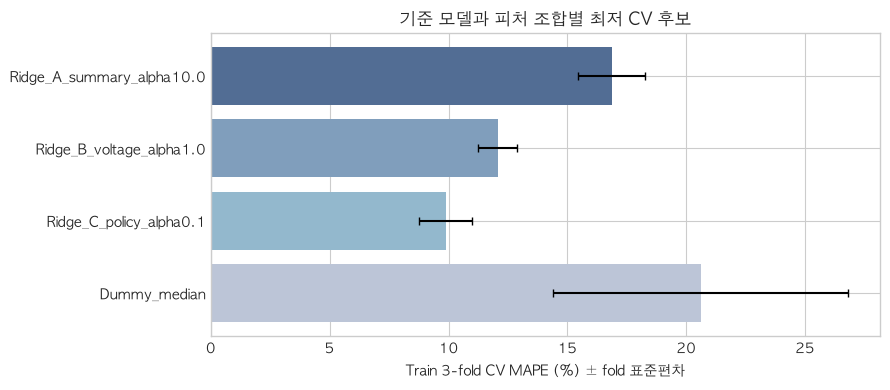

In [3]:
display(cv.round(4))
best = cv.sort_values("CV_MAPE_mean_pct").groupby("feature_set", sort=False).head(1)
dummy = cv[cv.model == "Dummy"]
comparison = pd.concat([dummy, best], ignore_index=True).drop_duplicates("candidate_id")
display(comparison[["candidate_id", "CV_MAPE_mean_pct", "CV_MAPE_std_pct"]].round(4))
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(comparison.candidate_id, comparison.CV_MAPE_mean_pct, xerr=comparison.CV_MAPE_std_pct,
        color=["#bcc5d7", "#93b8cd", "#809ebc", "#526d94"][:len(comparison)], capsize=3)
ax.set(xlabel="Train 3-fold CV MAPE (%) ± fold 표준편차", title="기준 모델과 피처 조합별 최저 CV 후보")
fig.tight_layout()
fig.savefig(OUT / "cv_feature_comparison.png", dpi=160)
plt.show()


### 기존 Train의 피처 축소 비교 — 후속 탐색

C1·SOC의 다중공선성과 도메인 해석을 바탕으로 원래 6변수, SOC 제외, C1 제외를 같은 Train 36셀·동일 3-fold에서 비교한다. 각 구성의 Ridge alpha 0.1/1/10을 비교하며 같은 alpha끼리의 결과도 함께 본다. 이 작업은 이미 Batch 2 결과를 관측한 뒤의 후속 탐색이다. 기존 선택 모델을 교체하지 않고 Validation·Batch 2를 재평가하지 않는다. 제공 라벨 기준의 비교이며 실제 EOL 예측 개선을 확정하지 않는다. 공식 후속 파일도 사용하지 않는다.


In [1]:
# 후속 탐색: 기존 Train과 같은 fold만 사용한다. Batch 2 예측은 하지 않는다.
from sklearn.model_selection import KFold
from src.models import pipeline, metrics

train_review = pd.read_csv(OUT / "batch1_features.csv").query('split == "train"').sort_values("cell_id").reset_index(drop=True)
columns = json.loads((OUT / "selected_model.json").read_text())["features"]
configurations = {
    "six_features": columns,
    "without_switch_soc": [c for c in columns if c != "charge_switch_soc"],
    "without_c1": [c for c in columns if c != "charge_c1_rate"],
}
frozen_files = [OUT / "selected_model.json", OUT / "selected_model.joblib", OUT / "test_evaluation.json", ROOT / "results/model_performance.csv"]
before = {path: path.read_bytes() for path in frozen_files}
stored_folds = pd.read_csv(OUT / "cv_fold_cells.csv").set_index("cell_id")
followup_rows = []
for configuration, inputs in configurations.items():
    for alpha in (0.1, 1.0, 10.0):
        fold_scores = []
        oof = np.full(len(train_review), np.nan)
        for fold_number, (fitting, held) in enumerate(KFold(3, shuffle=True, random_state=42).split(train_review), 1):
            assert stored_folds.loc[train_review.iloc[held].cell_id, "cv_fold"].eq(fold_number).all()
            model = pipeline({"model": "Ridge", "params": {"alpha": alpha}})
            model.fit(train_review.iloc[fitting][inputs], train_review.iloc[fitting].cycle_life)
            oof[held] = model.predict(train_review.iloc[held][inputs])
            fold_scores.append(metrics(train_review.iloc[held].cycle_life, oof[held])["MAPE_pct"])
        assert np.isfinite(oof).all()
        followup_rows.append({"configuration": configuration, "n_features": len(inputs), "alpha": alpha,
            "CV_MAPE_mean_pct": np.mean(fold_scores), "CV_MAPE_std_pct": np.std(fold_scores, ddof=1),
            **{f"fold{i+1}_MAPE_pct": value for i, value in enumerate(fold_scores)},
            **metrics(train_review.cycle_life, oof)})
followup = pd.DataFrame(followup_rows).sort_values(["CV_MAPE_mean_pct", "CV_MAPE_std_pct"])
original = pd.read_csv(OUT / "cv_candidate_results.csv").set_index("candidate_id")
for _, row in followup.query('configuration == "six_features"').iterrows():
    assert np.isclose(row.CV_MAPE_mean_pct, original.loc[f"Ridge_C_policy_alpha{row.alpha}", "CV_MAPE_mean_pct"], atol=1e-10)
assert all(path.read_bytes() == content for path, content in before.items())
followup.to_csv(OUT / "followup_train_feature_reduction_cv.csv", index=False)
display(followup.round(4))
display(followup.groupby("configuration", sort=False).head(1).round(4))


,configuration,n_features,alpha,CV_MAPE_mean_pct,CV_MAPE_std_pct,fold1_MAPE_pct,fold2_MAPE_pct,fold3_MAPE_pct,MAPE_pct,MAE_cycles,RMSE_cycles
0,six_features,6,0.1,9.8809,1.1101,11.0348,8.8205,9.7875,9.8809,78.6283,98.4455
1,six_features,6,1.0,10.1499,0.9665,10.9249,9.0669,10.4578,10.1499,81.0342,98.1353
7,without_c1,5,1.0,11.4660,0.3699,11.7673,11.0531,11.5775,11.4660,93.0019,108.4466
2,six_features,6,10.0,11.5482,1.0552,12.6186,10.5089,11.5170,11.5482,92.3176,108.7944
6,without_c1,5,0.1,11.5740,0.4451,12.0620,11.4694,11.1905,11.5740,94.4921,111.9695
5,without_switch_soc,5,10.0,11.5917,1.7043,13.2980,9.8894,11.5877,11.5917,91.2627,110.1291
4,without_switch_soc,5,1.0,11.6687,0.5783,12.3350,11.3738,11.2973,11.6687,94.7284,112.3039
3,without_switch_soc,5,0.1,11.8474,0.7394,12.5750,11.8705,11.0966,11.8474,96.8142,116.6940
8,without_c1,5,10.0,12.2568,1.0975,13.3047,11.1156,12.3500,12.2568,98.0727,113.3190


,configuration,n_features,alpha,CV_MAPE_mean_pct,CV_MAPE_std_pct,fold1_MAPE_pct,fold2_MAPE_pct,fold3_MAPE_pct,MAPE_pct,MAE_cycles,RMSE_cycles
0,six_features,6,0.1,9.8809,1.1101,11.0348,8.8205,9.7875,9.8809,78.6283,98.4455
7,without_c1,5,1.0,11.4660,0.3699,11.7673,11.0531,11.5775,11.4660,93.0019,108.4466
5,without_switch_soc,5,10.0,11.5917,1.7043,13.2980,9.8894,11.5877,11.5917,91.2627,110.1291


## 3. 고정 모델의 Validation·Batch 2 평가

Train은 최종 모델의 학습셋 재예측이 아니라 선택된 후보의 out-of-fold 예측으로 계산했다. 최종 모델은 Train 36셀로만 적합했다. 각 지표의 정의와 모델 학습 표본은 동일하게 유지했다. MAE·RMSE는 사이클 단위다.


,split,n_cells,MAPE_pct,MAE_cycles,RMSE_cycles,candidate_id
0,Train_CV,36,9.8809,78.6283,98.4455,Ridge_C_policy_alpha0.1
1,Valid,10,8.9327,84.6698,103.6344,Ridge_C_policy_alpha0.1
2,Test_Batch2,39,58.7329,274.0386,313.6859,Ridge_C_policy_alpha0.1


,gap,gap_percentage_points
0,Valid_minus_TrainCV,-0.9482
1,Test_minus_Valid,49.8002
2,Test_minus_9.1,49.6329


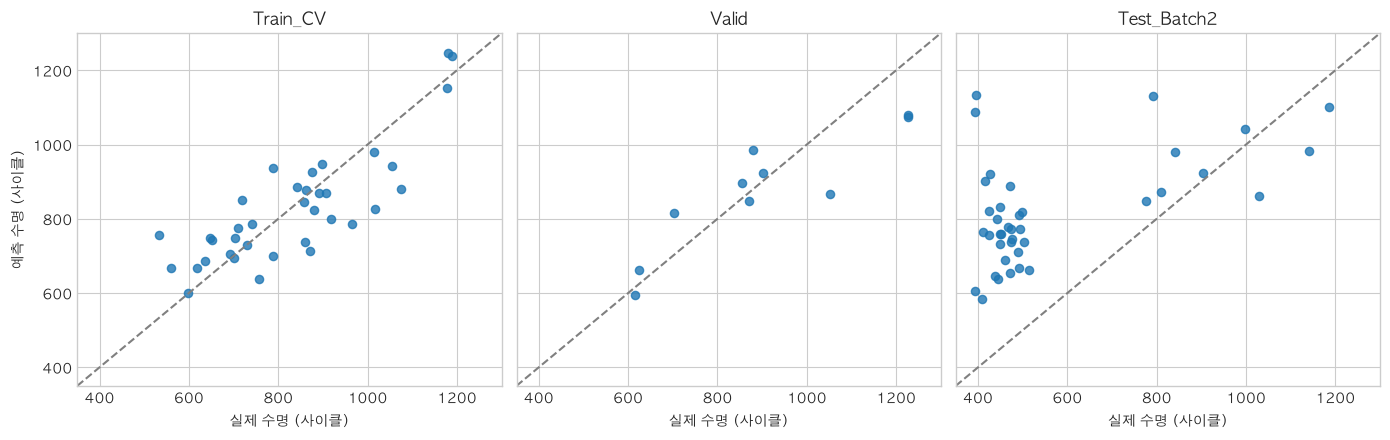

In [4]:
display(performance.round(4))
display(pd.read_csv(OUT / "performance_gaps.csv").round(4))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
for ax, role in zip(axes, ["Train_CV", "Valid", "Test_Batch2"]):
    part = predictions[predictions.split == role]
    ax.scatter(part.cycle_life, part.prediction, s=35, alpha=.8)
    ax.plot([350, 1300], [350, 1300], linestyle="--", color="gray")
    ax.set(title=role, xlabel="실제 수명 (사이클)", xlim=(350, 1300), ylim=(350, 1300))
axes[0].set_ylabel("예측 수명 (사이클)")
fig.tight_layout()
fig.savefig(OUT / "actual_vs_prediction.png", dpi=160)
plt.show()


## 4. Batch 2 오차와 학습 범위 차이

Test 결과를 본 뒤 모델을 다시 선택하지 않았다. 아래는 실패를 설명하기 위한 사후 분석이다. 입력별 최솟값·최댓값 비교는 범위 밖 관측을 찾는 기초 점검이며 분포 변화의 원인을 입증하지 않는다. 범위 안에서도 변수의 결합·정책 조건이 다를 수 있다.


In [5]:
test = predictions[predictions.split == "Test_Batch2"].copy()
test["newstructure"] = test.policy.str.contains("newstructure", regex=False)
policy_errors = test.groupby("policy").agg(셀수=("cell_id", "size"), 실제수명평균=("cycle_life", "mean"),
    예측수명평균=("prediction", "mean"), MAPE_pct=("APE_pct", "mean"), 평균오차_cycles=("error_cycles", "mean"))
policy_errors.to_csv(OUT / "batch2_policy_errors.csv")
display(policy_errors.round(3))
group_errors = test.groupby("newstructure").agg(셀수=("cell_id", "size"), MAPE_pct=("APE_pct", "mean"),
    평균오차_cycles=("error_cycles", "mean"))
group_errors.to_csv(OUT / "batch2_structure_errors.csv")
display(group_errors.round(3))
display(test.nlargest(5, "APE_pct").round(3))
train = features_b1[features_b1.split == "train"]
ranges = []
for col in selected["features"]:
    low, high = train[col].min(), train[col].max()
    ranges.append({"feature": col, "Train_min": low, "Train_max": high,
        "Test_min": features_b2[col].min(), "Test_max": features_b2[col].max(),
        "Test_outside_train_range": int(((features_b2[col] < low) | (features_b2[col] > high)).sum())})
ranges = pd.DataFrame(ranges)
ranges.to_csv(OUT / "feature_range_audit.csv", index=False)
display(ranges.round(5))


,셀수,실제수명평균,예측수명평균,MAPE_pct,평균오차_cycles
policy,,,,,
3.6C(30%)-6C,2,421.000,911.836,116.593,490.836
3.6C(9%)-5C,2,394.500,1110.729,181.537,716.229
4.65C(44%)-5C,2,482.500,797.671,65.365,315.171
4.65C(69%)-6C,2,452.000,664.557,46.972,212.557
4.8C(80%)-4.8C,5,483.600,673.313,39.476,189.713
4.8C(80%)-4.8C-newstructure,3,871.667,860.998,11.151,-10.668
5.2C(50%)-4.25C,5,454.000,766.136,69.075,312.136
5.2C(58%)-4C,4,477.750,747.453,56.674,269.703
5.2C(58%)-4C-newstructure,3,961.667,961.876,10.752,0.210


,셀수,MAPE_pct,평균오차_cycles
newstructure,,,
False,30,72.338,319.988
True,9,13.384,29.913


,batch,cell_id,policy,cycle_life,split,prediction,error_cycles,APE_pct,newstructure
61,Batch2,Batch2_c15,3.6C(9%)-5C,396.0,Test_Batch2,1132.628,736.628,186.017,False
52,Batch2,Batch2_c06,3.6C(9%)-5C,393.0,Test_Batch2,1088.830,695.830,177.056,False
51,Batch2,Batch2_c05,3.6C(30%)-6C,416.0,Test_Batch2,902.705,486.705,116.996,False
60,Batch2,Batch2_c14,3.6C(30%)-6C,426.0,Test_Batch2,920.967,494.967,116.189,False
75,Batch2,Batch2_c31,5.6C(26%)-4.5C,425.0,Test_Batch2,821.565,396.565,93.309,False


,feature,Train_min,Train_max,Test_min,Test_max,Test_outside_train_range
0,q_diff_100_2,-0.01138,0.00663,-0.02291,0.01278,12
1,t_max_100,31.65890,38.72872,31.86726,40.46694,8
2,delta_q_log_var,-5.01486,-3.35034,-4.44859,-3.08588,11
3,charge_c1_rate,3.60000,8.00000,3.60000,6.00000,0
4,charge_c2_rate,3.00000,5.40000,3.00000,6.00000,4
5,charge_switch_soc,15.00000,80.00000,9.00000,80.00000,2


## 5. 1차 결과와 함께 검토할 점

- Train CV **9.88%**, Validation **8.93%**, Batch 2 **58.73%** MAPE다. Validation이 목표 9.1%보다 낮아도 최종 Test 목표를 달성한 것은 아니다. 목표 대비 Test Gap은 **+49.63%p**다.
- A 요약 피처 최저 CV **16.87%**, B 전압 피처 추가 **12.07%**, C 정책 변수 추가 **9.88%**로 내부 점수는 개선됐다. 고정된 3-fold와 작은 표본에서의 비교이며 외부 배치 개선을 입증하지 않는다.
- Batch 2 일반 표기 30셀은 MAPE **72.34%**, newstructure 9셀은 **13.38%**다. 일반 표기 셀을 평균 약 **320사이클 과대예측**했다. 예를 들어 `Batch2_c15` 실제 396사이클을 약 1,133사이클로 예측했다.
- 학습 수명 최저는 534사이클이며 Batch 2의 짧은 수명 영역은 학습에서 충분히 관측되지 않았다. 용량 변화는 12셀, 최고온도는 8셀, 로그 분산은 11셀에서 Train 범위를 벗어났다. 단순 피처 범위 검사만으로 오차 원인을 확정하지 않는다.
- 어제 확인한 정책·배치 차이와 일반화 한계가 실제 성능에서도 나타났다. 지금 결과를 근거로 테스트 셀을 제외하거나 같은 Test로 재튜닝하지 않는다.

**다음 공동 검토:** 계산·분할·점수 정의가 타당한지 먼저 확인한다. 개선 실험은 정책 일반화 검증과 추가 데이터/실험 조건 확인을 우선 고려하며, Batch 2를 이미 관측한 후속 탐색임을 명시한다. 이번 고정 모델과 평가 결과는 기준 기록으로 보존한다.


### 공식 후속 파일 확보 이후의 갱신

공식 2017-06-30 자료를 data/reference_official에 별도로 확보했다. 기존 원본·라벨·모델은 유지한다. 앞선 ‘자료 미확보’는 그 시점의 이력이다. 공식 코드가 지정한 첫5셀의 후속 길이가 일치하며 후보 라벨은1852/2160/2237/1434/1709다. 이는 review_official_continuation_candidates.csv의 진단 후보이며 학습 입력에 반영하지 않았다.

후속 마지막 용량도 0.88Ah 바로 위이며 기존 B1 36셀도 마지막 값이0.885Ah 이하다. 따라서 +1만으로 모든 라벨이 잘못됐다고 단정하지 않는다. 연결 누락·실험 중단·수집 경계 규칙과 물리 셀 대응을 확인해야 한다. 후속 정책은 접두부가 없어 접미부 호환만 확인했다. 다운로드 출처·로컬 SHA-256은 official_reference_download.json에 보존했다.
